# 08 Final Business Insights

This notebook converts model outputs into clear business insights for viva/report/PPT.

**Input (from previous notebooks):**
- `outputs/final_customer_clusters_with_anomalies.csv` or `outputs/final_customer_clusters.csv`
- `outputs/clustering_metrics_comparison.csv`
- `outputs/association_rules_top.csv`
- `outputs/anomaly_summary.csv`

**Output:**
- `outputs/final_business_summary.json`
- `outputs/final_persona_table.csv`
- `outputs/final_recommendations.txt`

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

In [2]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"

clusters_path = OUTPUT_DIR / "final_customer_clusters_with_anomalies.csv"
if not clusters_path.exists():
    clusters_path = OUTPUT_DIR / "final_customer_clusters.csv"

metrics_path = OUTPUT_DIR / "clustering_metrics_comparison.csv"
rules_path = OUTPUT_DIR / "association_rules_top.csv"
anom_path = OUTPUT_DIR / "anomaly_summary.csv"

print("clusters:", clusters_path.exists(), clusters_path)
print("metrics:", metrics_path.exists())
print("rules:", rules_path.exists())
print("anomaly summary:", anom_path.exists())

clusters: True S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_customer_clusters_with_anomalies.csv
metrics: True
rules: True
anomaly summary: True


In [3]:
clusters = pd.read_csv(clusters_path)
metrics = pd.read_csv(metrics_path) if metrics_path.exists() else pd.DataFrame()
rules = pd.read_csv(rules_path) if rules_path.exists() else pd.DataFrame()
anom = pd.read_csv(anom_path) if anom_path.exists() else pd.DataFrame()

print("clusters shape:", clusters.shape)
print("metrics shape:", metrics.shape)
print("rules shape:", rules.shape)
print("anom shape:", anom.shape)
clusters.head()

clusters shape: (1000, 31)
metrics shape: (4, 7)
rules shape: (0, 5)
anom shape: (1, 6)


,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days,avg_customer_age,dominant_gender,cluster_kmeans,cluster_dbscan,cluster_gmm,cluster_hierarchical,selected_model,cluster_label,frequency_count_feat,monetary_total_feat,avg_order_value_feat,weekend_ratio_feat,lunch_ratio_feat,snacks_ratio_feat,dinner_ratio_feat,last_date_feat,recency_days_feat,avg_customer_age_feat,dominant_gender_feat,anomaly_flag,anomaly_score
0,CUST1001,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M,2,-1,2,4,KMeans,2,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M,0,0.030148
1,CUST1002,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F,2,0,2,0,KMeans,2,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F,0,0.126714
2,CUST1003,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M,2,0,2,0,KMeans,2,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M,0,0.105963
3,CUST1004,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F,1,1,1,1,KMeans,1,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F,0,0.103941
4,CUST1005,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M,4,-1,4,3,KMeans,4,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M,0,0.027882


In [4]:
# Basic KPI snapshot
kpis = {
    "total_customers": int(len(clusters)),
    "n_clusters": int(clusters["cluster_label"].nunique()) if "cluster_label" in clusters.columns else None,
    "selected_model": str(clusters["selected_model"].dropna().iloc[0]) if "selected_model" in clusters.columns and clusters["selected_model"].notna().any() else "Unknown",
    "anomaly_count": int(clusters["anomaly_flag"].sum()) if "anomaly_flag" in clusters.columns else None,
    "anomaly_rate": float(clusters["anomaly_flag"].mean()) if "anomaly_flag" in clusters.columns else None,
    "top_rules_count": int(len(rules)),
}
kpis

{'total_customers': 1000,
 'n_clusters': 5,
 'selected_model': 'KMeans',
 'anomaly_count': 40,
 'anomaly_rate': 0.04,
 'top_rules_count': 0}

In [5]:
# Persona table from cluster means
profile_cols = [
    c for c in [
        "frequency_count",
        "monetary_total",
        "avg_order_value",
        "recency_days",
        "weekend_ratio",
        "lunch_ratio",
        "snacks_ratio",
        "dinner_ratio",
        "anomaly_flag",
    ]
    if c in clusters.columns
]

if "cluster_label" in clusters.columns and profile_cols:
    persona = clusters.groupby("cluster_label")[profile_cols].mean().round(3)
    persona["customers"] = clusters.groupby("cluster_label").size()
    persona = persona.reset_index().sort_values("customers", ascending=False)
else:
    persona = pd.DataFrame()

persona

,cluster_label,frequency_count,monetary_total,avg_order_value,recency_days,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,anomaly_flag,customers
2,2,1.0,94.427,94.427,89.104,0.187,0.808,0.0,0.000,0.000,375
1,1,1.0,125.374,125.374,88.752,0.257,0.000,0.0,1.000,0.050,222
0,0,1.0,94.798,94.798,91.822,0.178,0.000,1.0,0.000,0.006,163
3,3,1.0,248.108,248.108,93.044,0.437,0.797,0.0,0.013,0.114,158
4,4,1.0,244.720,244.720,81.110,0.537,0.000,1.0,0.000,0.122,82


In [6]:
# Simple persona naming logic (editable)
def name_persona(row):
    freq = row.get("frequency_count", 0)
    mon = row.get("monetary_total", 0)
    lunch = row.get("lunch_ratio", 0)
    weekend = row.get("weekend_ratio", 0)

    if mon >= persona["monetary_total"].quantile(0.75) if "monetary_total" in persona.columns and len(persona) > 0 else False:
        return "High Value Loyalists"
    if lunch >= 0.5:
        return "Lunch Regulars"
    if weekend >= 0.45:
        return "Weekend Visitors"
    if freq <= (persona["frequency_count"].median() if "frequency_count" in persona.columns and len(persona) > 0 else 0):
        return "Occasional Buyers"
    return "Balanced Segment"

if not persona.empty:
    persona["persona_name"] = persona.apply(name_persona, axis=1)

persona

,cluster_label,frequency_count,monetary_total,avg_order_value,recency_days,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,anomaly_flag,customers,persona_name
2,2,1.0,94.427,94.427,89.104,0.187,0.808,0.0,0.000,0.000,375,Lunch Regulars
1,1,1.0,125.374,125.374,88.752,0.257,0.000,0.0,1.000,0.050,222,Occasional Buyers
0,0,1.0,94.798,94.798,91.822,0.178,0.000,1.0,0.000,0.006,163,Occasional Buyers
3,3,1.0,248.108,248.108,93.044,0.437,0.797,0.0,0.013,0.114,158,High Value Loyalists
4,4,1.0,244.720,244.720,81.110,0.537,0.000,1.0,0.000,0.122,82,High Value Loyalists


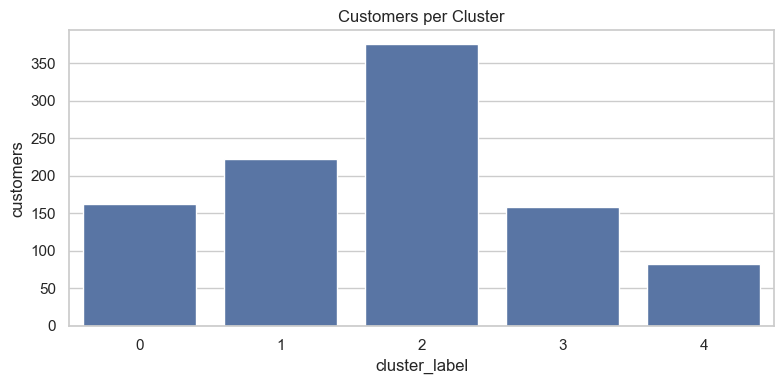

In [7]:
# Visual: cluster sizes
if not persona.empty and "customers" in persona.columns:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=persona, x="cluster_label", y="customers")
    plt.title("Customers per Cluster")
    plt.tight_layout()
    plt.show()

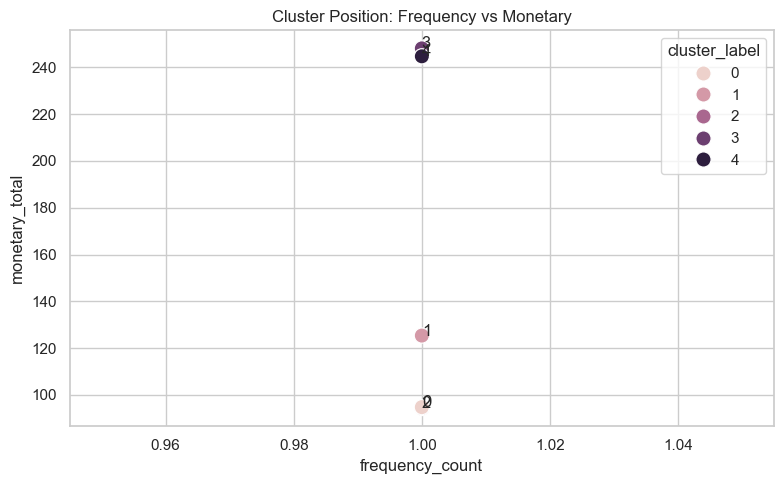

In [8]:
# Visual: monetary vs frequency by cluster
if not persona.empty and {"monetary_total", "frequency_count"}.issubset(persona.columns):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=persona, x="frequency_count", y="monetary_total", hue="cluster_label", s=120)
    for _, r in persona.iterrows():
        plt.text(r["frequency_count"], r["monetary_total"], str(r["cluster_label"]))
    plt.title("Cluster Position: Frequency vs Monetary")
    plt.tight_layout()
    plt.show()

In [9]:
# Build recommendation lines from personas + top rules
recommendations = []

if not persona.empty:
    for _, r in persona.iterrows():
        pname = r.get("persona_name", f"Cluster {r.get('cluster_label')}")
        c = int(r.get("customers", 0))
        recs = []

        if r.get("lunch_ratio", 0) >= 0.5:
            recs.append("Introduce lunch combo offers and pre-order discounts.")
        if r.get("weekend_ratio", 0) >= 0.4:
            recs.append("Run weekend-only bundles and family packs.")
        if r.get("avg_order_value", 0) >= (persona["avg_order_value"].median() if "avg_order_value" in persona.columns else 0):
            recs.append("Push premium add-ons and dessert upsells.")
        if r.get("anomaly_flag", 0) >= 0.1:
            recs.append("Monitor unusual behavior and verify edge cases in transactions.")

        if not recs:
            recs.append("Maintain current mix and test small A/B promotional campaigns.")

        recommendations.append({
            "cluster_label": int(r.get("cluster_label", -1)),
            "persona_name": pname,
            "customers": c,
            "recommendations": " ".join(recs),
        })

if len(rules) > 0:
    recommendations.append({
        "cluster_label": -1,
        "persona_name": "Cross-Sell Rules",
        "customers": 0,
        "recommendations": "Use top association rules to suggest frequent item pairs at checkout.",
    })

recommend_df = pd.DataFrame(recommendations)
recommend_df

,cluster_label,persona_name,customers,recommendations
0,2,Lunch Regulars,375,Introduce lunch combo offers and pre-order dis...
1,1,Occasional Buyers,222,Push premium add-ons and dessert upsells.
2,0,Occasional Buyers,163,Maintain current mix and test small A/B promot...
3,3,High Value Loyalists,158,Introduce lunch combo offers and pre-order dis...
4,4,High Value Loyalists,82,Run weekend-only bundles and family packs. Pus...


In [10]:
# Save final report artifacts
summary_path = OUTPUT_DIR / "final_business_summary.json"
persona_path = OUTPUT_DIR / "final_persona_table.csv"
reco_path = OUTPUT_DIR / "final_recommendations.txt"
reco_csv_path = OUTPUT_DIR / "final_recommendations.csv"

payload = {
    "kpis": kpis,
    "top_recommendation_count": int(len(recommend_df)),
    "notes": "Final insight package for viva and report.",
}
summary_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

if not persona.empty:
    persona.to_csv(persona_path, index=False)
if not recommend_df.empty:
    recommend_df.to_csv(reco_csv_path, index=False)

lines = []
lines.append("FINAL RECOMMENDATIONS")
lines.append("=" * 25)
lines.append("")
for _, row in recommend_df.iterrows():
    lines.append(f"- {row['persona_name']} (cluster {row['cluster_label']}): {row['recommendations']}")

reco_path.write_text("\n".join(lines), encoding="utf-8")

print("Saved:")
print("-", summary_path)
if persona_path.exists():
    print("-", persona_path)
if reco_csv_path.exists():
    print("-", reco_csv_path)
print("-", reco_path)

Saved:
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_business_summary.json
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_persona_table.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_recommendations.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_recommendations.txt


## Viva Script (Short)

- I used transactional cafeteria data and engineered behavioral customer features.
- I trained and compared multiple unsupervised models.
- I selected the final model using metric + interpretability checks.
- I detected anomalies and extracted association rules for item recommendations.
- I converted model outputs into segment-wise business actions.